In [1]:
from conf.default import get_cfg_defaults
from Noise2Model.data import preprocessing, get_png_img_paths, parse_file_name
from Noise2Model.trainer import get_trainer_class

In [2]:
!gpustat

Merlin                      Wed Jan 21 12:21:55 2026  576.02
[0] NVIDIA GeForce RTX 4090 | 48°C,  14 % |  1919 / 24564 MB |
[1] NVIDIA GeForce RTX 4090 | 31°C,   0 % |     0 / 24564 MB |


In [3]:
from torch.cuda import is_available
print(is_available())

True


In [4]:
img_path = '../../_data/04-mito-20x-noise1/'

In [5]:
img_paths = get_png_img_paths(img_path)[:1]

for img_idx, imgpath in enumerate((img_paths)):
    print(f'Processing image {img_idx+1}/{len(img_paths)}: {imgpath}')

Processing image 1/1: {'GT': '../../_data/04-mito-20x-noise1/GT/mito-20x-noise1-0020.png', 'NOISY': '../../_data/04-mito-20x-noise1/raw/mito-20x-noise1-0020.png'}


In [6]:
parse_file_name(imgpath)

{'scene-instance-number': 20,
 'scene-number': 1,
 'optical-setup': 3,
 'camera': 0,
 'exposure-time': 60,
 'wavelength': 600,
 'sample-code': 0}

In [7]:
import cv2
img_gt = cv2.imread(imgpath['GT'], cv2.IMREAD_ANYDEPTH)

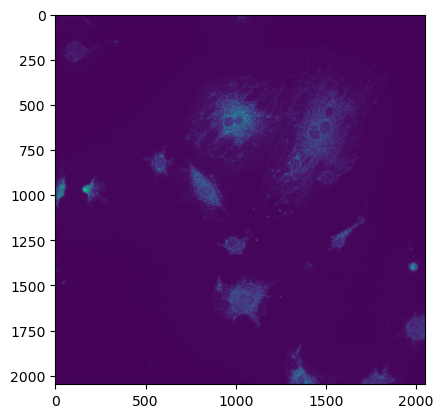

In [8]:
import matplotlib.pyplot as plt 
plt.imshow(img_gt)

In [9]:
preprocessing(img_path,
              patch_size= 96,
              step= 80,
              output_base_path='../../_data/HDF5_04-mito-20x-noise1_s96_o08', 
              get_img_paths_func=get_png_img_paths,
              parse_config=parse_file_name,
              train_noisegen_idx=[i for i in range(1,10)],
              test_idx=[99],
              overwrite=True,)

100%|██████████| 100/100 [00:08<00:00, 12.43it/s]


../../_data/HDF5_04-mito-20x-noise1_s96_o08/noise_gen/test/0088_GT.hdf5
(1, 96, 96)


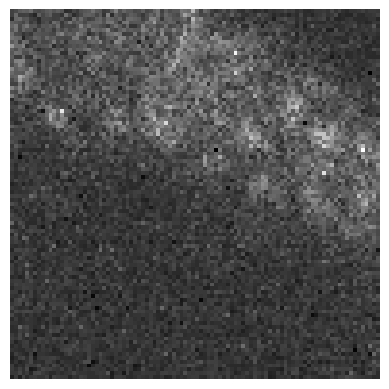

(1, 96, 96)


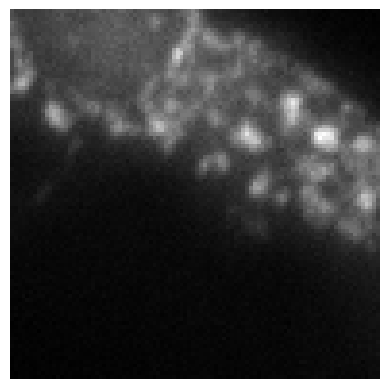

In [20]:
from Noise2Model.data import load_and_display_hdf5_image
output_base_path = '../../_data/HDF5_04-mito-20x-noise1_s96_o08'
file_path = output_base_path + '/noise_gen/test/0088_GT.hdf5'
print(file_path)
for i in range(70,71):
    load_and_display_hdf5_image(file_path, dataset_name='noisy', patch_num=i)
    img = load_and_display_hdf5_image(file_path, dataset_name='clean', patch_num=i)

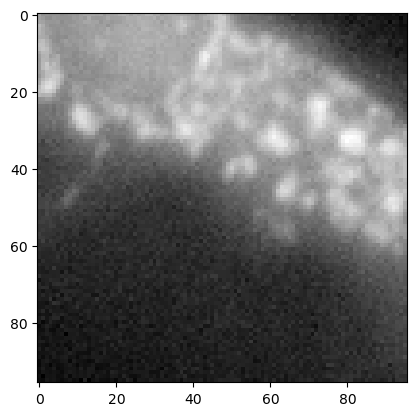

In [31]:
import matplotlib.pyplot as plt
from numpy import log
plt.imshow((log(img[0])), 'gray')

In [ ]:
# from Noise2Model.utils import save_img
# dir_name = '/home/biagio/Noise2Model/nbs/demos'
# file_name = 'test.png'
# save_img(dir_name,file_name, img)

In [ ]:
device = '1'

config = get_cfg_defaults()
config.merge_from_file('../../conf/NMFlowGAN_NoiseModeler5.yaml')


In [ ]:
# intialize trainer
trainer = get_trainer_class(config.BASE.trainer)(config)
trainer.set_device(device)
trainer.train()
